<h1 style="text-align: center; color: RED">AIRLINE PASSENGER SATISFACTION VERİ SETİNİN ANALİZİ</h1>

Bu veri seti bir havayolu yolcu memnuniyeti anketi içerir. Uçak yolcularının seyahat sürecine dair yaşadığı deneyimleri (hizmet kalitesi, konfor, gecikme süresi, rezervasyon kolaylığı gibi) analiz ederek, hangi faktörlerin memnuniyet üzerinde en çok etkili olduğunu ortaya koymaktır.

**Veri Setinde Bulunan Değişkenler:**

id:	Kimlik Numarası / Yolcu ID

Gender:	Cinsiyet

Customer Type:	Müşteri Türü

Age:	Yaş

Type of Travel:	Seyahat Türü

Class:	Uçuş Sınıfı

Flight Distance:	Uçuş Mesafesi

Inflight wifi service:	Uçak İçi Wi-Fi Hizmeti

Departure/Arrival time convenient:	Kalkış/Varış Saati Uygunluğu

Ease of Online booking:	Çevrimiçi Rezervasyon Kolaylığı

Gate location:	Kapı Konumu / Kapıya Uzaklık

Food and drink:	Yiyecek ve İçecek Hizmeti

Online boarding:	Çevrimiçi Biniş İşlemi

Seat comfort:	Koltuk Konforu

Inflight entertainment:	Uçak İçi Eğlence

On-board service:	Uçuş Sırasındaki Hizmet

Leg room service:	Bacak Mesafesi Hizmeti

Baggage handling:	Bagaj İşlemleri

Checkin service:	Check-in Hizmeti

Inflight service:	Uçak İçi Hizmetler

Cleanliness:	Temizlik

Departure Delay in Minutes:	Kalkış Gecikmesi (Dakika)

Arrival Delay in Minutes:	Varış Gecikmesi (Dakika)

satisfaction:	Memnuniyet

<h2 style="text-align: center; color:red">1-GENEL RESİM</h2>

* Bu kısmın amacı elimize bir veri geldiğinde hızlı bir şekilde elimizdeki fonksiyonlar ile veriyi analiz etmektir.

In [146]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.width',500)
pd.set_option('display.max_columns', None)

In [17]:
#test veri setini okuduk
df_test = pd.read_csv("C:\\Users\\ASLI\\Desktop\\Patikadev-Kız Başına Bootcamp\\1.Final_Case\\Veriseti\\test.csv",index_col=0)

In [19]:
#train veri setini okuduk
df_train = pd.read_csv("C:\\Users\\ASLI\\Desktop\\Patikadev-Kız Başına Bootcamp\\1.Final_Case\\Veriseti\\train.csv",index_col=0)

* Eğitim (train) ve test veri setleri, özellik mühendisliği ve veri analizi adımlarının tüm veri üzerinde tutarlı biçimde uygulanabilmesi için bu aşamada birleştirilmiştir.

In [33]:
df_test.shape #test setindeki gözlem ve değişken sayıları incelendi

(25976, 24)

In [69]:
df_test.head()

,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,19556,Female,Loyal Customer,52,Business travel,Eco,160,5,4,3,4,3,4,3,5,5,5,5,2,5,5,50,44.0,satisfied
1,90035,Female,Loyal Customer,36,Business travel,Business,2863,1,1,3,1,5,4,5,4,4,4,4,3,4,5,0,0.0,satisfied
2,12360,Male,disloyal Customer,20,Business travel,Eco,192,2,0,2,4,2,2,2,2,4,1,3,2,2,2,0,0.0,neutral or dissatisfied
3,77959,Male,Loyal Customer,44,Business travel,Business,3377,0,0,0,2,3,4,4,1,1,1,1,3,1,4,0,6.0,satisfied
4,36875,Female,Loyal Customer,49,Business travel,Eco,1182,2,3,4,3,4,1,2,2,2,2,2,4,2,4,0,20.0,satisfied


In [31]:
df_train.shape #train setindeki gözlem ve değişken sayıları incelendi

(103904, 24)

In [23]:
df_train.head()

,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [25]:
df = pd.concat([df_test,df_train], axis=0).reset_index(drop=True)

In [81]:
df.shape #test-train seti birleştirildikten sonraki gözlem ve değişken sayıları incelendi

(129880, 24)

* Bu kısımda belli metotları kullanarak veriyi hızlı bir şekilde inceleyerek veri setini tanımaya çalışıcaz.

In [75]:
def check_df(dataframe, head = 5):
    print('##############SHAPE##############')
    print(dataframe.shape)
    print('##############TYPES##############')
    print(dataframe.dtypes)
    print('##############COLUMNS#####################')
    print(dataframe.columns)
    print('##############HEAD######################')
    print(dataframe.head(head))
    print('##############TAİL#####################')
    print(dataframe.tail(head))
    print('##############DESCRİBE##########################')
    print(dataframe.describe([0, 0.05,0.25, 0.50,0.75, 0.95, 0.99, 1]).T)
    print('##############NULL#####################')
    print(dataframe.isnull().sum())
check_df(df)

##############SHAPE##############
(129880, 24)
##############TYPES##############
id                                     int64
Gender                                object
Customer Type                         object
Age                                    int64
Type of Travel                        object
Class                                 object
Flight Distance                        int64
Inflight wifi service                  int64
Departure/Arrival time convenient      int64
Ease of Online booking                 int64
Gate location                          int64
Food and drink                         int64
Online boarding                        int64
Seat comfort                           int64
Inflight entertainment                 int64
On-board service                       int64
Leg room service                       int64
Baggage handling                       int64
Checkin service                        int64
Inflight service                       int64
Cleanliness        

* Veri setinde toplam 24 değişken ve 129880 tane gözlem bulunmaktadır.
* Veri setinde sayısal, kategorik ve float veri tipinde değişkenler mevcut. Bazı değişkenler 1-5 arasında memnuniyet skorları ile puanlandırılmış. Bunlar sayısal veri olarak görünsede aslında kategorik değişken. Analiz yaparken bunları kategorik değişken olarak değerlendiricez.

<h3 style="text-align: center; color:red">ANALİZ İÇİN SAYISAL VE KATEGORİK DEĞİŞKENLERİN BELİRLENMESİ </h3

Veri setinde yer alan değişkenlerin türleri, uygulanacak analiz yöntemlerinin belirlenmesi açısından büyük önem taşımaktadır. Bu nedenle analiz sürecine başlamadan önce, değişkenleri veri tiplerine göre sınıflandırmak hedeflenmiştir.

Bu aşamada:

* Sayısal (numerik) değişkenler,

* Kategorik (nitel) değişkenler,

* Ve anlamlı bir ölçüm değeri taşımayan, ancak çok sayıda benzersiz değere sahip olan kardinal değişkenler (high cardinality features)

ayrıştırılmıştır.Bu sınıflandırma sayesinde, her bir değişken grubu için uygun analiz stratejileri belirlenecek; özet istatistikler ve görselleştirme adımları ilgili veri tipine göre özelleştirilmiştir.

In [51]:
def grab_col_names(dataframe, cat_th=10, car_th=20):#parametrelerin ön tanımlı değerlerini burda belirttik
    """
    Veri setindeki kategorik, numerik ve kategorik fakat kardinal degiskenlerin isimlerini verir.--
    Parameters
    ----------
    dataframe: dataframe
        degisken isimleri alınmak istenen dataframedir.
    cat_th: int, float
        numerik fakat kategorik olan degiskenler için sınıf eşik degeri
    car_th: int, float
        kategorik fakat kardinal degiskenler icin sınıf esik degeri

    Returns
    -------
    cat_cols: list
        kategorik degisken listesi
    num_cols: list
        numerik degisken listesi
    cat_but_car: list
        kategorik gorunumlu kardinal degisken listesi
    Notes
    -------
    cat_cols+num_cols+cat_but_car=toplam degisken sayısı
    num_but_cat cat_cols'un içerisindedir.
    Return olan 3 liste toplamı degisken sayısına eşittir: cat_cols +num_cols+cat_but_car
    """
    cat_cols = [col for col in dataframe.columns if str(dataframe[col].dtypes) in ['object', 'category', 'bool']]
    num_but_cat = [col for col in dataframe.columns if dataframe[col].dtypes in ['int64', 'float64'] and dataframe[col].nunique() < cat_th]
    cat_but_car = [col for col in dataframe.columns if str(dataframe[col].dtypes) in ['object', 'category'] and dataframe[col].nunique() > car_th]
    cat_cols = cat_cols + num_but_cat
    cat_cols = [col for col in cat_cols if col not in cat_but_car] 

    num_cols = [col for col in dataframe.columns if dataframe[col].dtypes  in ['int64', 'float64']] #bu sayısal değişkenleri verir
    num_cols = [col for col in num_cols if col not in cat_cols] 

    print(f'Observetions: {dataframe.shape[0]}')
    print(f'Variables: {dataframe.shape[1]}')
    print(f'cat_cols: {len(cat_cols)}')
    print(f'num_cols: {len(num_cols)}')
    print(f'cat_but_car: {len(cat_but_car)}')
    print(f'num_but_cat: {len(num_but_cat)}')

    return cat_cols, num_cols, cat_but_car

cat_cols, num_cols, cat_but_car = grab_col_names(df)

Observetions: 129880
Variables: 24
cat_cols: 19
num_cols: 5
cat_but_car: 0
num_but_cat: 14


In [53]:
cat_cols

['Gender',
 'Customer Type',
 'Type of Travel',
 'Class',
 'satisfaction',
 'Inflight wifi service',
 'Departure/Arrival time convenient',
 'Ease of Online booking',
 'Gate location',
 'Food and drink',
 'Online boarding',
 'Seat comfort',
 'Inflight entertainment',
 'On-board service',
 'Leg room service',
 'Baggage handling',
 'Checkin service',
 'Inflight service',
 'Cleanliness']

In [55]:
num_cols #ıd değişkeni aslında kardinal bir değişken yani bizim için bir ölçüm değeri taşımıyor 
        # bu sebeble bu listeden cıkarılıcak

['id',
 'Age',
 'Flight Distance',
 'Departure Delay in Minutes',
 'Arrival Delay in Minutes']

In [71]:
num_cols = [col for col in num_cols if col!='id']#ıd değişkenini numerik değişken listesinden cıkardık

In [73]:
num_cols

['Age',
 'Flight Distance',
 'Departure Delay in Minutes',
 'Arrival Delay in Minutes']

In [57]:
cat_but_car

[]

<h3 style="text-align: center; color:red">İSTATİSTİKSEL ÖZET </h3

Bu kısımda describe metodu ile değişkelerin istatistiksel özetlerine bakılmıştır. describe() metodu, veri setinde bulunan değişkenlerin dağılımları, merkezi eğilimleri ve özet istatistiklerini otomatik olarak sunarak, veriyi hızlı ve etkili bir şekilde anlamamazı sağlar. Bazı değişkenleri yorumlamaya çalışalım.

**AGE:**

Mininum değeri 7 yani en küçük yolcu yedi yaşında iken max değeri yani en yaşlı yolcu 85 yaşında. Çeyreklik değerlere bakıldığında aykırı değer yok gibi duruyor.Ortalama ve medyan birbirine çok yakın (39.42 ve 40), bu da yaş dağılımının simetrik veya yakın simetrik olduğunu gösterir. Yani yaşların çoğu 40 civarında yoğunlaşmış.Ancak standart sapmanın yüksek olması nedeniyle yaşlar geniş bir aralıkta dağılıyor.

**Departure Delay in Minutes:** 

Ortalama gecikme 14.7 dakika, ancak medyan (50%) 0 dakika. Bu durum, verinin büyük çoğunluğunda (en az %50’sinde) uçuşların zamanında veya çok az gecikmeyle kalktığını gösteriyor.Standart sapma (38 dakika) ortalamadan oldukça yüksek, bu da bazı uçuşların çok daha uzun gecikmeler yaşadığını ifade ediyor.Bu bize verinin çarpık olduğunu gösteriyor. Max gecikme ile %95'lik dilimlerdeki gecikmelere bakıldığında arada ciddi bir fark görünüyor. Bu bizi acaab aykırı değer var mı sorusuna yönlendiriyor.


In [91]:
df.describe([0.01, 0.05,0.25, 0.50,0.75, 0.95, 0.99, 1])

,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129487.000000
mean,64940.500000,39.427957,1190.316392,2.728696,3.057599,2.756876,2.976925,3.204774,3.252633,3.441361,3.358077,3.383023,3.350878,3.632114,3.306267,3.642193,3.286326,14.713713,15.091129
std,37493.270818,15.119360,997.452477,1.329340,1.526741,1.401740,1.278520,1.329933,1.350719,1.319289,1.334049,1.287099,1.316252,1.180025,1.266185,1.176669,1.313682,38.071126,38.465650
min,1.000000,7.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1%,1299.790000,8.000000,101.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000
5%,6494.950000,15.000000,176.950000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,32470.750000,27.000000,414.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000
50%,64940.500000,40.000000,844.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000,0.000000,0.000000
75%,97410.250000,51.000000,1744.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,5.000000,4.000000,12.000000,13.000000
95%,123386.050000,64.000000,3380.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,77.000000,78.000000


<h3 style="text-align: center; color:red">EKSİK DEĞER ANALİZİ </h3

Eksik değer, bir veri setinde bazı gözlemlerin belirli değişkenler için bilgi içermemesi durumudur. Yani bir hücrede beklenen veri yoksa, bu eksik değer (missing value) olarak adlandırılır.Eksik değerler birçok nedenle ortaya çıkmış olabilir. Eksik değerleri tespit ettikten sonra bunlara nasıl müdahale edileceğine karar verilmelidir.

In [97]:
df.isnull().sum()#hangi değişkende kaçar tane eksik değer olduğunu gözlemlememizi sağlar.

id                                     0
Gender                                 0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Inflight wifi service                  0
Departure/Arrival time convenient      0
Ease of Online booking                 0
Gate location                          0
Food and drink                         0
Online boarding                        0
Seat comfort                           0
Inflight entertainment                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Inflight service                       0
Cleanliness                            0
Departure Delay in Minutes             0
Arrival Delay in Minutes             393
satisfaction                           0
dtype: int64

In [99]:
df[df.isnull().any(axis=1)] #sutunlara göre bir satırda en az bi tane eksik değer varsa yazdırır 

,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
516,107365,Female,Loyal Customer,21,Personal Travel,Eco,632,1,5,1,4,2,1,4,2,4,2,5,4,5,2,9,NaN,neutral or dissatisfied
656,108648,Male,Loyal Customer,9,Personal Travel,Eco,762,2,5,2,2,4,2,1,4,2,5,2,5,2,4,51,NaN,neutral or dissatisfied
1071,16797,Male,disloyal Customer,25,Business travel,Eco,1017,3,4,4,5,5,4,5,5,2,5,2,3,2,5,126,NaN,neutral or dissatisfied
1224,30090,Male,Loyal Customer,7,Personal Travel,Eco,399,4,5,4,4,4,4,4,4,4,3,1,1,4,4,0,NaN,neutral or dissatisfied
1589,41924,Female,Loyal Customer,58,Business travel,Eco,129,5,3,3,3,3,5,5,5,5,5,5,3,5,5,3,NaN,satisfied
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128043,36729,Male,Loyal Customer,49,Personal Travel,Eco Plus,1249,2,5,2,3,2,3,3,3,4,5,4,3,4,3,230,NaN,neutral or dissatisfied
128360,71241,Male,Loyal Customer,58,Business travel,Eco,733,3,3,3,3,3,3,3,3,3,1,2,4,2,3,55,NaN,neutral or dissatisfied
128528,27684,Female,disloyal Customer,29,Business travel,Eco,1107,2,1,1,1,5,1,3,5,4,1,5,5,3,5,0,NaN,neutral or dissatisfied
128936,36787,Male,Loyal Customer,58,Business travel,Eco,1088,4,4,1,1,5,4,5,5,1,5,5,5,3,5,0,NaN,satisfied


In [101]:
def missing_values_table(dataframe, na_name=False):
    #sadece eksik değerler sahip değişkenlerin isimleri
    na_columns = [col for col in dataframe.columns if dataframe[col].isnull().sum() > 0]

    #eksik değer olan değişkenleri azalan sıraya göre sıralanır.
    n_miss = dataframe[na_columns].isnull().sum().sort_values(ascending=False)
    
    #eksik değerlerin veri setine göre oranı
    ratio = (dataframe[na_columns].isnull().sum() / dataframe.shape[0] * 100).sort_values(ascending=False)
    
    #Eksik değerlerin sayısı ve oranı n_miss ve ratio değişkenlerinden alınarak birleştirilir
    missing_df = pd.concat([n_miss, np.round(ratio, 2)], axis=1, keys=['n_miss', 'ratio'])
    print(missing_df, end="\n")

    if na_name:
        return na_columns

In [103]:
missing_values_table(df, False)

                          n_miss  ratio
Arrival Delay in Minutes     393    0.3


['Arrival Delay in Minutes']

* Veri setimizde Arrival Delay in Minutes( Varış Gecikmesi (Dakika)) değişkeninde eksik değer bulunmaktadır. Veri setindeki gözlem sayısına bakıldığında 0.3'luk oran az bir değer sayılabilir.

**Eksik değerleri tespit ettik. Bu eksik değerler problemini bir kaç yöntem ile çözebiliriz:**
 
  1- Veri seti gözlem açısından zengin ise eksik değerleri veri setinden silebiliriz.
  
  2- Basit atama yöntemleri ile eksik değerleri doldurabiliriz.Arrival Delay in Minutes  sayısal  bir  değişken eksik değerleri bu değişkenin medianı yada ortalaması ile doldurmayı tercih edebiliriz.
  
  3-Kategorik değişken kırılımlarında değer atayabiliriz. Örneğin cinsiyete göre kırılım alıp ortalaması ile doldurmak gibi ya da Type of Travel değişkenine göre kırılım yapıp ortalama ya da medaianı ile doldurmak gibi
  
  4-Tahmine Dayalı Atama ile Doldurma (Bir makine öğrenmesi modeli tekniği oluşturarak tahmine dayalı doldurma)
  

<h3 style="text-align: center; color:red">AYKIRI  DEĞER ANALİZİ </h3

Aykırı değer, bir veri setinde diğer gözlemlerden önemli ölçüde farklı olan, yani ortalamanın çok dışında kalan veri noktalarıdır.Bu değerler genellikle verideki hatalardan, nadir olaylardan, ya da gerçekten var olan olağandışı durumlardan kaynaklanır.

Aykırı değer analizi yapılırken bir kaç yöntem kullanılabilir.

1- Box plot yöntemi

2- IQR Yöntemi

3- Z-Skoru yöntemi



In [117]:
#IQR İLE AYKIRI DEĞER ANALİZİ
#0.25 ve 0.75 değerleri teoride kullanılan değerlerdir. Bu değerler analizcinin insiyatifine bağlı olarak değiştirilebilir.

def outlier_thresholds(dataframe, col_name, q1=0.25,q3=0.75):
    quartile1=dataframe[col_name].quantile(q1)#Verilerin %25’inin altında kaldığı değer
    quartile3=dataframe[col_name].quantile(q3)#Verilerin %75’inin altında kaldığı değer
    IQR = quartile3 - quartile1 #Q3 - Q1, yani ortadaki %50’lik dilimin aralığı
    #Alt ve üst sınır belirlenerek bunların dışında kalan değerler aykırı değer olarak kabul edilecek.
    up_limit = quartile3 + IQR *1.5
    low_limit = quartile1 - IQR * 1.5
    return low_limit, up_limit
    
 

In [123]:
#Sayısal değerler için up ve low limit sınırları bunların dışında kalanlar aykırı değerdir.
for col in num_cols:
    print(col,outlier_thresholds(df, col ))

Age (-9.0, 87.0)
Flight Distance (-1581.0, 3739.0)
Departure Delay in Minutes (-18.0, 30.0)
Arrival Delay in Minutes (-19.5, 32.5)


In [166]:
#aykırı değer olan değişkenleri belirlemek için yazılan fonksiyon
def check_outliers(dataframe, col_name):
    lower_bound, upper_bound = outlier_thresholds(dataframe, col_name)
    outliers = dataframe[(dataframe[col_name] < lower_bound) | (dataframe[col_name] > upper_bound)]
    return outliers

In [168]:
#Bu fonksiyon değişken ismi girildiğinde aykırı değer var mı yok mu sorgusu yapar ve değişkendeki aykırı değer oranını belirtir.
for col in num_cols:
    outliers = check_outliers(df, col)
    outlier_ratio = 100 * outliers.shape[0] / df.shape[0]
    print(f"{col}: {outliers.shape[0]} aykırı değer var ({outlier_ratio:.2f}%)")

Age: 0 aykırı değer var (0.00%)
Flight Distance: 2855 aykırı değer var (2.20%)
Departure Delay in Minutes: 18098 aykırı değer var (13.93%)
Arrival Delay in Minutes: 17492 aykırı değer var (13.47%)


**Not**: İstatistiksel özet tabloda yer alan çeyreklik değerler incelendiğinde, üç değişkende potansiyel aykırı değerlerolabileceğini yorumlamıştık. Bu noktada, ilgili değişkenlerdeki aykırılıkların gerçek hayattaki olağan senaryolardan mı kaynaklandığı yoksa veri giriş hatası gibi anomali durumlarından mı kaynaklandığı detaylı şekilde analiz edilmelidir. Örneğin, ‘Varış Gecikmesi’ değişkenindeki yüksek gecikme değerleri operasyonel koşullarda gerçekleşebilir mi, yoksa bu durum veri bütünlüğü ile ilgili bir sorun mu işaret ediyor, gibi sorular analiz için önemli olabilir.

Bir sonraki aşama ise bu aykırı değerlere ne yapabiliriz sorusudur?

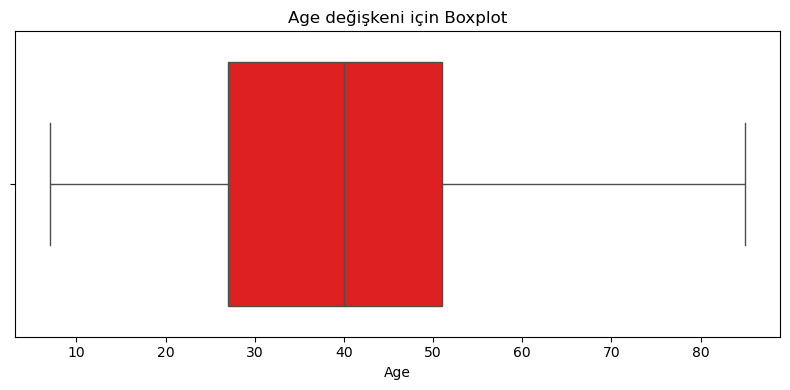

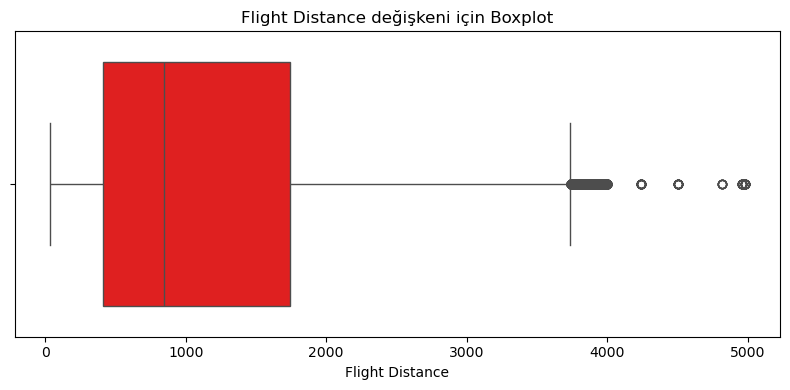

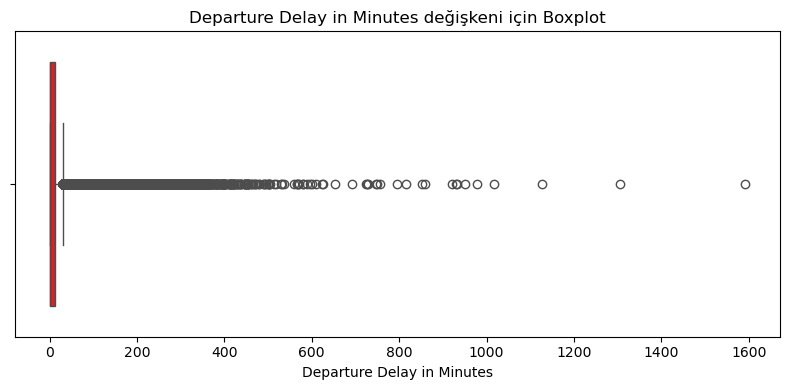

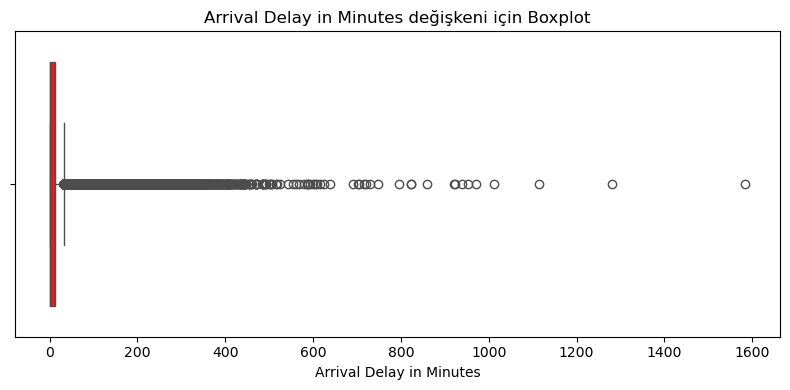

In [152]:
#BOXPLOT İLE AYKIRI DEĞER ANALİZİ
for col in num_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col], color='r')
    plt.title(f'{col} değişkeni için Boxplot')
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

<h3 style="text-align: center; color:red">DEĞİŞKENLERİN GÖRSELLEŞTİRİLMESİ </h3

**1-KATEGORİK DEĞİŞKEN ANALİZİ**

İlk aşamada grab_col_names fonksiyonu ile kategorik ve sayısal değişkenlerimizi belirlemiştik.cat_cols listesinde kategorik değişkenler ve sayısal görünümlü kategorik değişkenler bulunmaktadır.Kategorik değişkenlerin sınıf sayılarını, oranlarını ve sütun grafiği ile görselleştirilmesini sağlayan fonksiyonu yazalım.

In [197]:
def cat_summary(dataframe, col_name,plot=False):
    print(pd.DataFrame({col_name:dataframe[col_name].value_counts(),
                        'Ratio':100*dataframe[col_name].value_counts() / dataframe.shape[0]}))
    print('################################################')

    if plot:
        sns.countplot(data=dataframe, x=dataframe[col_name],palette='viridis')
        plt.show()
    

        Gender      Ratio
Gender                   
Female   65899  50.738374
Male     63981  49.261626
################################################


C:\Users\ASLI\AppData\Local\Temp\ipykernel_3532\2616264187.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=dataframe, x=dataframe[col_name],palette='viridis')


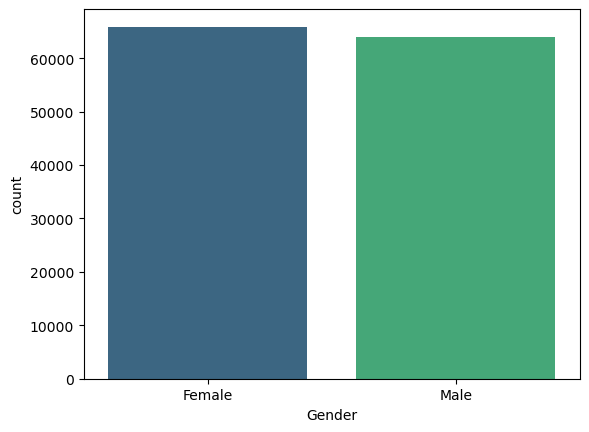

                   Customer Type      Ratio
Customer Type                              
Loyal Customer            106100  81.690791
disloyal Customer          23780  18.309209
################################################


C:\Users\ASLI\AppData\Local\Temp\ipykernel_3532\2616264187.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=dataframe, x=dataframe[col_name],palette='viridis')


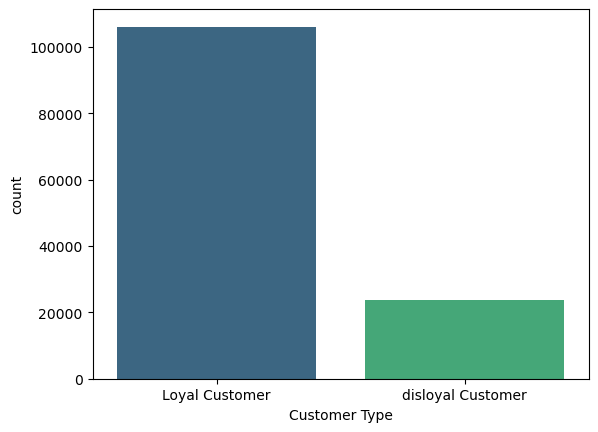

C:\Users\ASLI\AppData\Local\Temp\ipykernel_3532\2616264187.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=dataframe, x=dataframe[col_name],palette='viridis')


                 Type of Travel      Ratio
Type of Travel                            
Business travel           89693  69.058362
Personal Travel           40187  30.941638
################################################


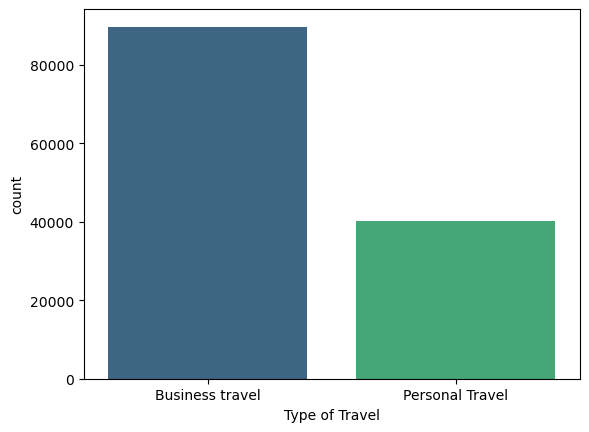

          Class      Ratio
Class                     
Business  62160  47.859563
Eco       58309  44.894518
Eco Plus   9411   7.245919
################################################


C:\Users\ASLI\AppData\Local\Temp\ipykernel_3532\2616264187.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=dataframe, x=dataframe[col_name],palette='viridis')


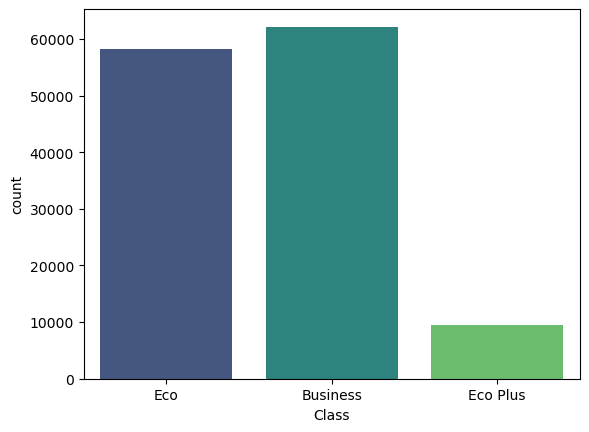

                         satisfaction      Ratio
satisfaction                                    
neutral or dissatisfied         73452  56.553742
satisfied                       56428  43.446258
################################################


C:\Users\ASLI\AppData\Local\Temp\ipykernel_3532\2616264187.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=dataframe, x=dataframe[col_name],palette='viridis')


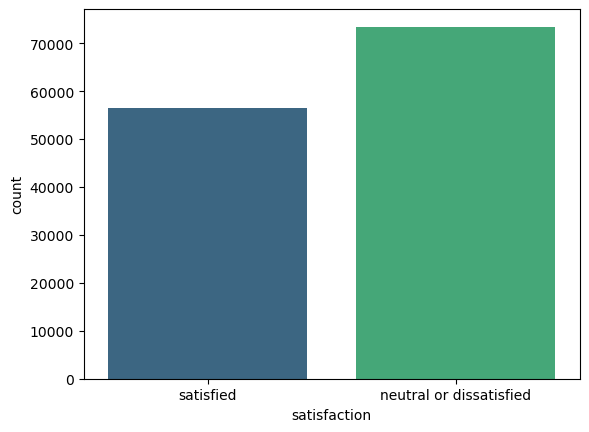

C:\Users\ASLI\AppData\Local\Temp\ipykernel_3532\2616264187.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=dataframe, x=dataframe[col_name],palette='viridis')


                       Inflight wifi service      Ratio
Inflight wifi service                                  
2                                      32320  24.884509
3                                      32185  24.780567
4                                      24775  19.075300
1                                      22328  17.191253
5                                      14356  11.053280
0                                       3916   3.015091
################################################


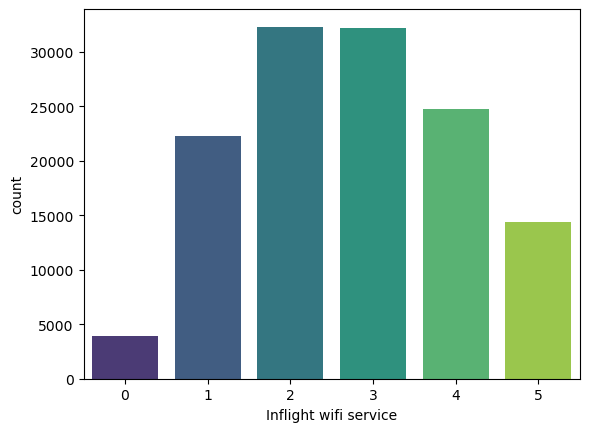

C:\Users\ASLI\AppData\Local\Temp\ipykernel_3532\2616264187.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=dataframe, x=dataframe[col_name],palette='viridis')


                                   Departure/Arrival time convenient      Ratio
Departure/Arrival time convenient                                              
4                                                              31880  24.545735
5                                                              27998  21.556822
3                                                              22378  17.229751
2                                                              21534  16.579920
1                                                              19409  14.943794
0                                                               6681   5.143979
################################################


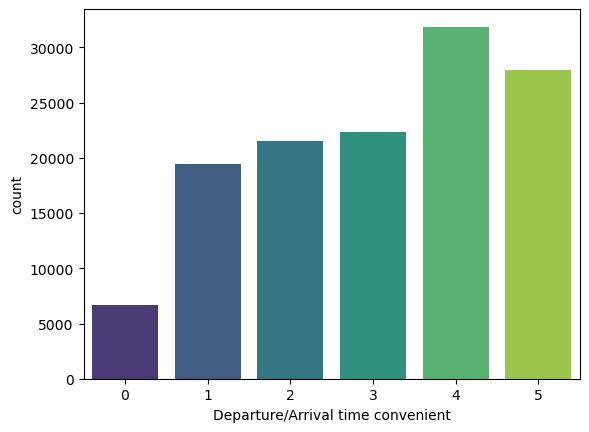

                        Ease of Online booking      Ratio
Ease of Online booking                                   
3                                        30393  23.400832
2                                        30051  23.137512
4                                        24444  18.820450
1                                        21886  16.850939
5                                        17424  13.415460
0                                         5682   4.374808
################################################


C:\Users\ASLI\AppData\Local\Temp\ipykernel_3532\2616264187.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=dataframe, x=dataframe[col_name],palette='viridis')


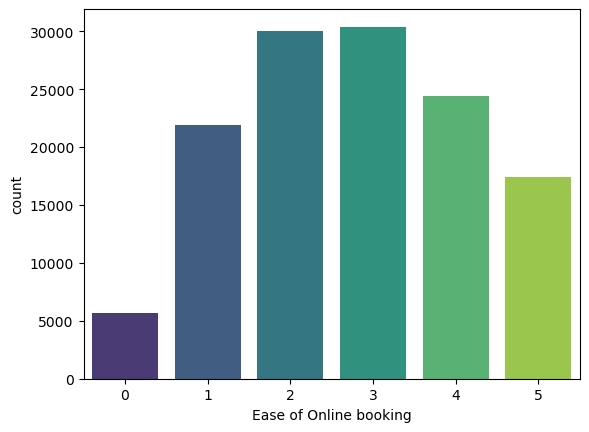

               Gate location      Ratio
Gate location                          
3                      35717  27.500000
4                      30466  23.457037
2                      24296  18.706498
1                      21991  16.931783
5                      17409  13.403911
0                          1   0.000770
################################################


C:\Users\ASLI\AppData\Local\Temp\ipykernel_3532\2616264187.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=dataframe, x=dataframe[col_name],palette='viridis')


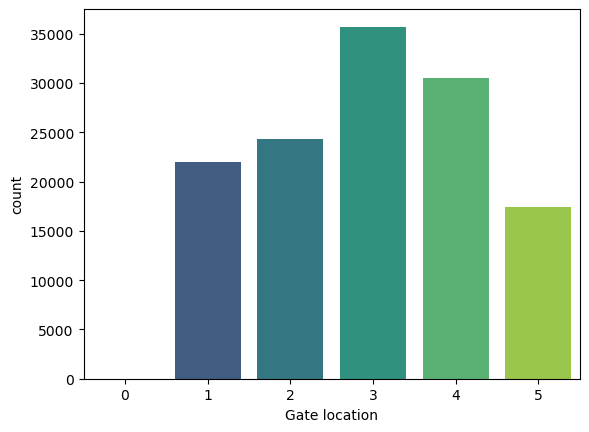

                Food and drink      Ratio
Food and drink                           
4                        30563  23.531722
5                        27957  21.525254
3                        27794  21.399754
2                        27383  21.083308
1                        16051  12.358331
0                          132   0.101632
################################################


C:\Users\ASLI\AppData\Local\Temp\ipykernel_3532\2616264187.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=dataframe, x=dataframe[col_name],palette='viridis')


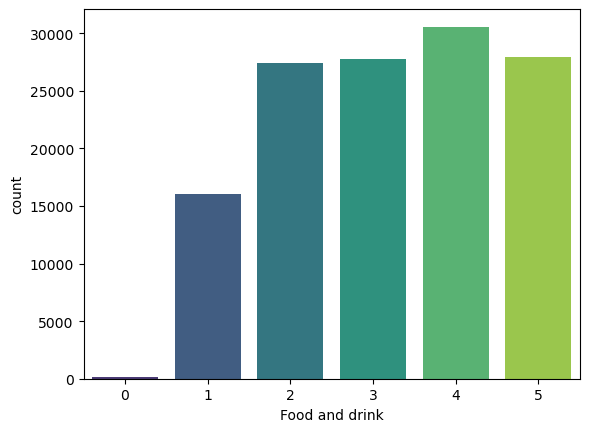

C:\Users\ASLI\AppData\Local\Temp\ipykernel_3532\2616264187.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=dataframe, x=dataframe[col_name],palette='viridis')


                 Online boarding      Ratio
Online boarding                            
4                          38468  29.618109
3                          27117  20.878503
5                          26020  20.033877
2                          21934  16.887897
1                          13261  10.210194
0                           3080   2.371420
################################################


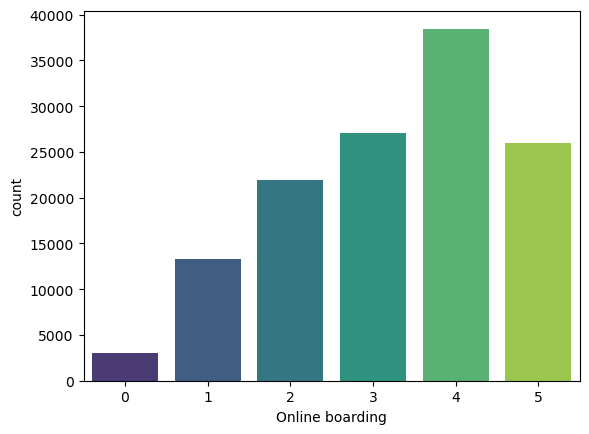

C:\Users\ASLI\AppData\Local\Temp\ipykernel_3532\2616264187.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=dataframe, x=dataframe[col_name],palette='viridis')


              Seat comfort      Ratio
Seat comfort                         
4                    39756  30.609794
5                    33158  25.529720
3                    23328  17.961195
2                    18529  14.266246
1                    15108  11.632276
0                        1   0.000770
################################################


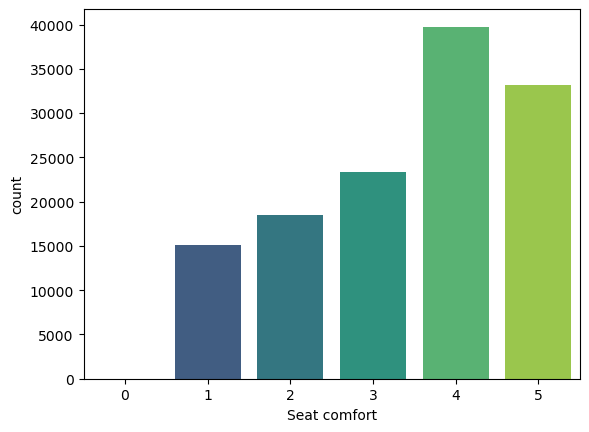

                        Inflight entertainment      Ratio
Inflight entertainment                                   
4                                        36791  28.326917
5                                        31544  24.287034
3                                        23884  18.389282
2                                        21968  16.914075
1                                        15675  12.068833
0                                           18   0.013859
################################################


C:\Users\ASLI\AppData\Local\Temp\ipykernel_3532\2616264187.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=dataframe, x=dataframe[col_name],palette='viridis')


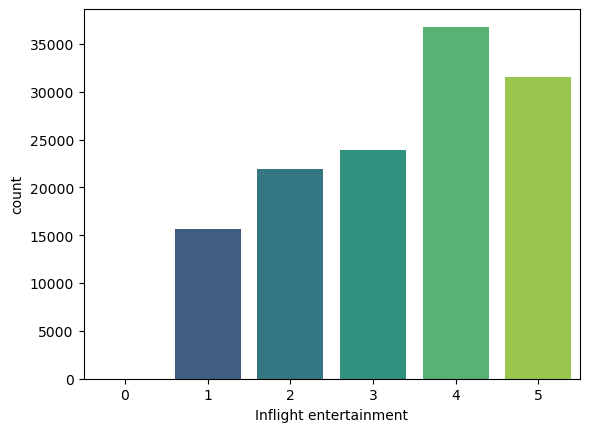

                  On-board service      Ratio
On-board service                             
4                            38703  29.799045
5                            29492  22.707114
3                            28542  21.975670
2                            18351  14.129196
1                            14787  11.385125
0                                5   0.003850
################################################


C:\Users\ASLI\AppData\Local\Temp\ipykernel_3532\2616264187.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=dataframe, x=dataframe[col_name],palette='viridis')


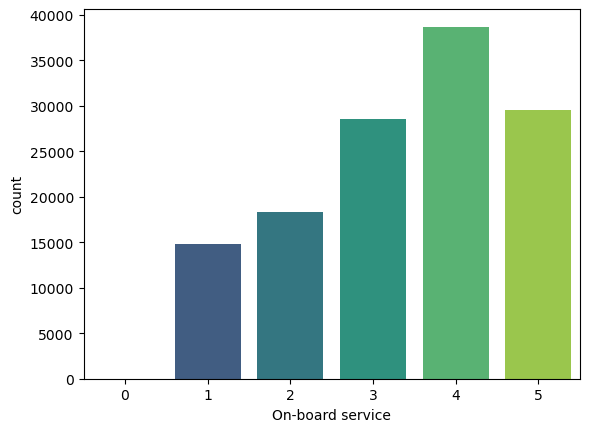

C:\Users\ASLI\AppData\Local\Temp\ipykernel_3532\2616264187.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=dataframe, x=dataframe[col_name],palette='viridis')


                  Leg room service      Ratio
Leg room service                             
4                            35886  27.630120
5                            30905  23.795042
3                            25056  19.291654
2                            24540  18.894364
1                            12895   9.928395
0                              598   0.460425
################################################


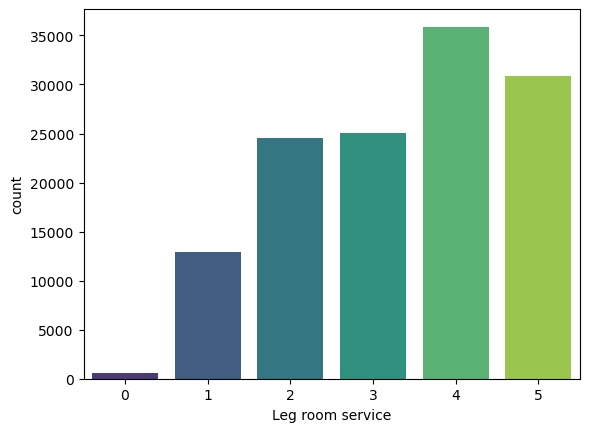

C:\Users\ASLI\AppData\Local\Temp\ipykernel_3532\2616264187.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=dataframe, x=dataframe[col_name],palette='viridis')


                  Baggage handling      Ratio
Baggage handling                             
4                            46761  36.003234
5                            33878  26.084078
3                            25851  19.903757
2                            14362  11.057900
1                             9028   6.951032
################################################


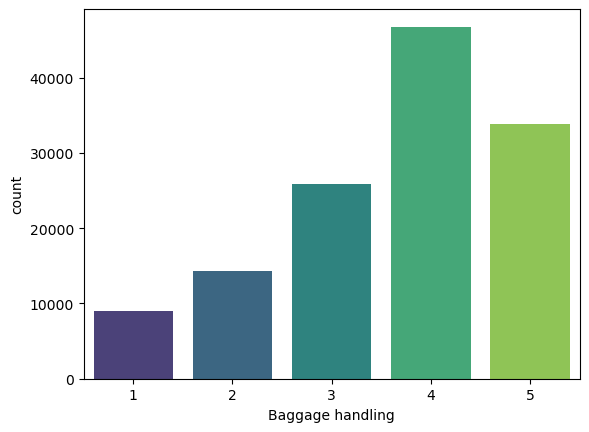

C:\Users\ASLI\AppData\Local\Temp\ipykernel_3532\2616264187.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=dataframe, x=dataframe[col_name],palette='viridis')


                 Checkin service      Ratio
Checkin service                            
4                          36333  27.974284
3                          35453  27.296735
5                          25883  19.928395
1                          16108  12.402217
2                          16102  12.397598
0                              1   0.000770
################################################


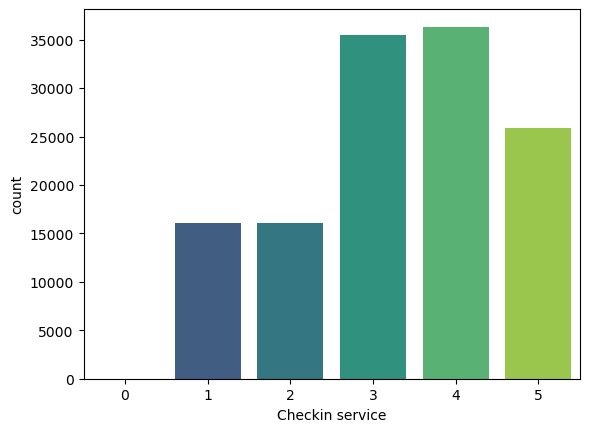

                  Inflight service      Ratio
Inflight service                             
4                            47323  36.435941
5                            34066  26.228827
3                            25316  19.491839
2                            14308  11.016323
1                             8862   6.823221
0                                5   0.003850
################################################


C:\Users\ASLI\AppData\Local\Temp\ipykernel_3532\2616264187.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=dataframe, x=dataframe[col_name],palette='viridis')


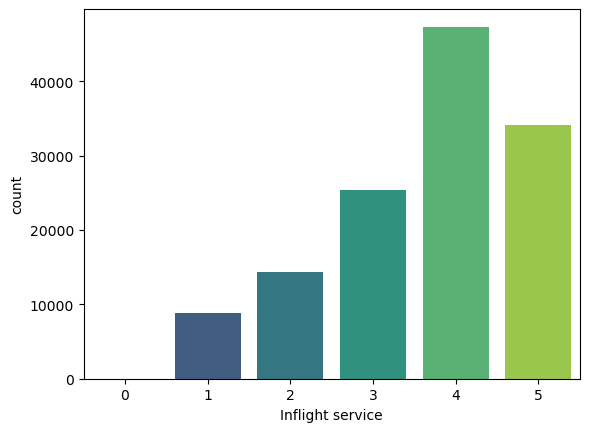

C:\Users\ASLI\AppData\Local\Temp\ipykernel_3532\2616264187.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=dataframe, x=dataframe[col_name],palette='viridis')


             Cleanliness      Ratio
Cleanliness                        
4                  33969  26.154142
3                  30639  23.590237
5                  28416  21.878657
2                  20113  15.485833
1                  16729  12.880351
0                     14   0.010779
################################################


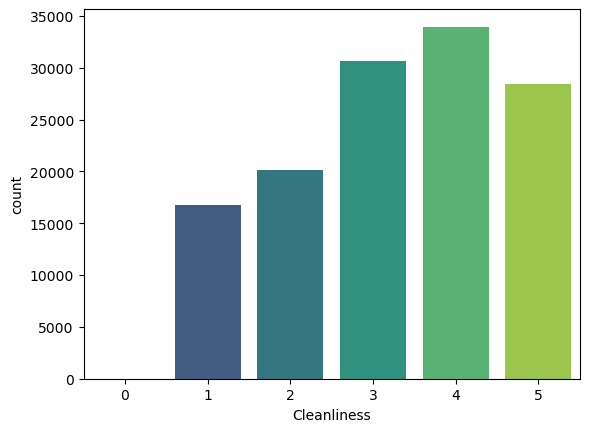

In [199]:
for col in cat_cols:
    cat_summary(df, col,plot=True)
    

Yukarıda görselleştirdiğimiz birkaç kategorik değişken için yorum yapmaya çalışalım:
* Gender:Veri setindeki yolcuların yaklaşık %50.7’si kadın, %49.3’ü ise erkek.Cinsiyet dağılımı oldukça dengeli olup, veri setinde her iki grubun da temsiliyeti güçlüdür.
* Satisfaction:%56 lık kesim nötr ya da memnuniyetsizken %43'lük kesim memnun görünüyor.Bu sonuçlardan memnun olmayan yolcuların sayıca fazla olduğunu ve bu grubun neden memnun olmadığını analiz etmenin önemli bir nokta olabileceğini görebiliriz. 
* Departure/Arrival time convenient : Oranlara baktığımızda en yüksek oran puan 4 (%24.55) ve puan 5 (%21.56) için gözlemlenmiş. Bu da, yolcuların önemli bir kısmının uçuş saatlerini genel olarak uygun bulduğunu gösteriyor. Ancak orta seviyede (puan 2–3) ve düşük seviyede (0–1) uygunluk puanı verenlerin toplamı da %53’e yakın. Bu, uçuş zamanlarının bir kısmının hala geniş bir yolcu kitlesi için ideal olmadığını düşündürebilir.

Tabi değişkenleri incelerken değişkenlerin birbiri ile olan ilişkilerini de inceleyip korelasyonlarına bakmak bizim için daha faydalı olacaktır.

**1-SAYISAL DEĞİŞKEN ANALİZİ**

In [249]:
def num_summary(dataframe, col_name, plot = False):
    print('###########',col_name,'##############')
    quantiles = [0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 0.99 ]
    print(dataframe[col_name].describe(quantiles)) #sayısal değişkenlerin betimsel istatistikleri
    print('################################')

    if plot:
        sns.histplot(data=df, x=dataframe[col_name], color="red", bins=10, kde=True)
        plt.title(" Değişken Dağılımı (Histogram + KDE)")
        plt.xlabel(col_name)
        plt.ylabel("Frekans")
        plt.grid(True)
        plt.show()

########### Age ##############
count    129880.000000
mean         39.427957
std          15.119360
min           7.000000
5%           15.000000
10%          20.000000
20%          25.000000
30%          30.000000
40%          36.000000
50%          40.000000
60%          44.000000
70%          49.000000
80%          54.000000
90%          59.000000
99%          70.000000
max          85.000000
Name: Age, dtype: float64
################################


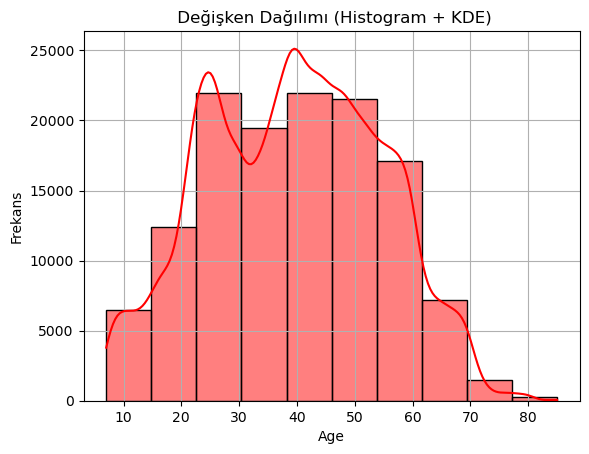

########### Flight Distance ##############
count    129880.000000
mean       1190.316392
std         997.452477
min          31.000000
5%          176.950000
10%         236.000000
20%         358.000000
30%         483.000000
40%         631.000000
50%         844.000000
60%        1050.000000
70%        1513.000000
80%        2072.000000
90%        2751.000000
99%        3884.000000
max        4983.000000
Name: Flight Distance, dtype: float64
################################


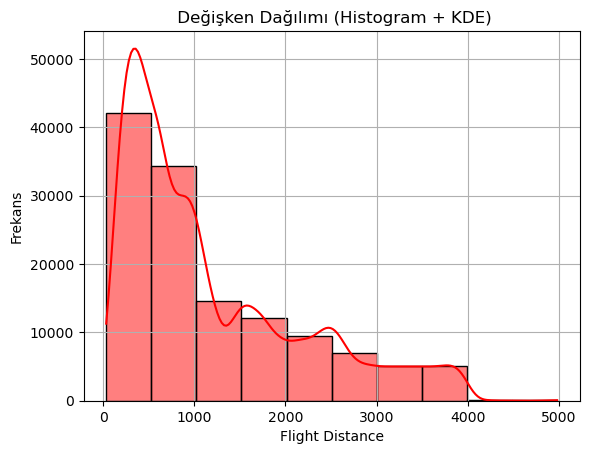

########### Departure Delay in Minutes ##############
count    129880.000000
mean         14.713713
std          38.071126
min           0.000000
5%            0.000000
10%           0.000000
20%           0.000000
30%           0.000000
40%           0.000000
50%           0.000000
60%           2.000000
70%           8.000000
80%          19.000000
90%          44.000000
99%         180.000000
max        1592.000000
Name: Departure Delay in Minutes, dtype: float64
################################


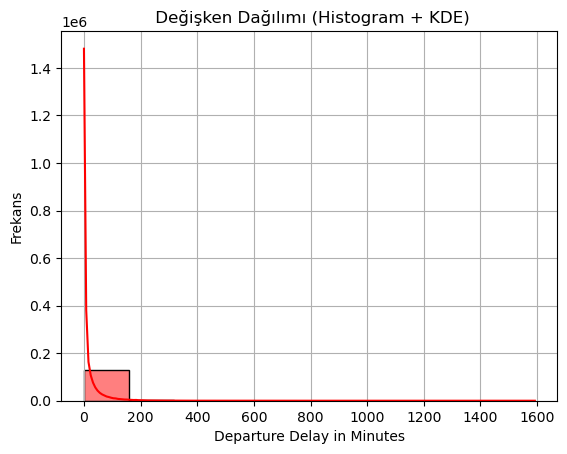

########### Arrival Delay in Minutes ##############
count    129487.000000
mean         15.091129
std          38.465650
min           0.000000
5%            0.000000
10%           0.000000
20%           0.000000
30%           0.000000
40%           0.000000
50%           0.000000
60%           2.000000
70%           9.000000
80%          19.000000
90%          44.000000
99%         182.000000
max        1584.000000
Name: Arrival Delay in Minutes, dtype: float64
################################


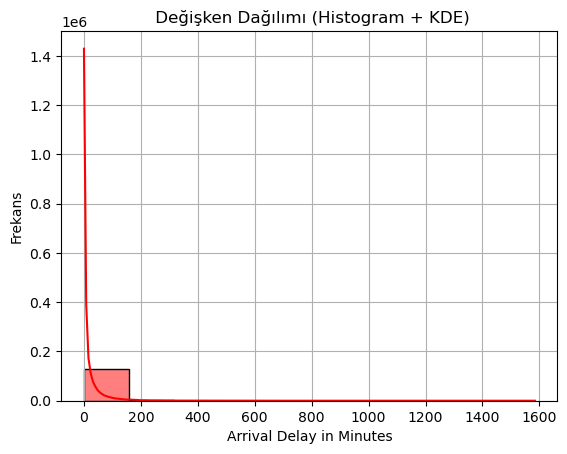

In [251]:
for col in num_cols:
    num_summary(df, col, plot = True)